# gait05 (2026-07-16) — RR calf demag sweep, heading-lock, vx=0.3

Policy: `Unitree-Go2-Flat-MethodA-Electric-DeployDR-Gait05-v0`,
checkpoint `logs/rsl_rl/go2_methoda_deploydr_gait05/2026-07-16_13-05-31_seed42/model_4999.pt`.

Only `RR_calf_joint` is demagnetized (plant-side `Kt·gr`, `Ke·gr` scaled by
`factor`; controller stays at nominal `Kt`/`Ke` — unaware of the fault).

| case | factor | demag severity | in comparison plots? |
|---|---|---|---|
| healthy | 1.0 | 0% | yes |
| RR_0.90 | 0.9 | 10% | yes |
| RR_0.80 | 0.8 | 20% | yes |
| RR_0.70 | 0.7 | 30% | yes |
| RR_0.60 | 0.6 | 40% | no (V_bus section only) |
| RR_0.40 | 0.4 | 60% | no (V_bus section only) |

The main plots focus on healthy/10%/20%/30% — mild-to-moderate severity
where the trend is still legible. 40%/60% break the gait down badly enough
that they were excluded from the trend plots (still loaded, and used later
for the V_bus/current-saturation counterfactual, where the severe fault is
the point).

Command: `vx=0.3`, `vy=0`, heading-lock **on** (`target_heading=0.0`). Rollout:
1000 steps @ policy dt=20ms = 20 s. Videos:
`./videos/gait05_{healthy,RR_0.90,RR_0.80,RR_0.70,RR_0.60,RR_0.40}.mp4`.

**Bug found and fixed while building this notebook** — the demag script
(copied from `results/heading_lock_compare/`) had a stale
`KT_NOMINAL_JOINT = KE_NOMINAL_JOINT = 0.128 * 6.33 = 0.8102` constant. The
robot's actual config (`go2_constants.py: _GO2_MOTOR_PHYS`, used by
`GO2_METHODA_CALF`) is `Kt = Ke = 0.26 N*m/A`, `gear_ratio = 6.33` → true
nominal `Kt·gr = Ke·gr = 1.6458` (verified live via
`actuator._Ktgr == 1.6458`). Since `inject_demagnetization()` *sets* an
absolute value (`gainprm = KT_NOMINAL_JOINT * factor`) rather than scaling
whatever nominal was already there, the stale constant meant factor
0.8/0.6/0.4 actually injected **60.6% / 70.5% / 80.3%** severity, not the
intended 20/40/60% — which is why the first pass showed RR_0.60 / RR_0.40
unable to make any forward progress at all. Fixed to `0.26 * 6.33` in
`run_demag_experiment.py`; all data below is the corrected re-run (old
mislabeled run archived under `_archive_wrong_kt0.128/`, with a written
explanation in `NOTE_kt_bug.md`).

## What's plotted

Metric selection is informed by what a real Go2 reports, per
`~/unitree_go2_deploy/data/real/260708_*/parsed/joint_states.csv` /
`target_joint_states.csv` (columns `<joint>/pos`, `<joint>/vel`,
`<joint>/effort` — no raw phase current) — but since this is simulation, the
torque panel uses the true ground-truth value rather than reconstructing a
driver-side estimate:

- **angle** — `q_all` (rad, solid) overlaid with `q_des` (dashed), the
  policy's commanded target before the PD converts it to torque. Comparable
  to `joint_states.csv` `/pos` and `target_joint_states.csv` `/pos`.
- **angular velocity** — `qd_all` (rad/s), comparable to `/vel`.
- **actual torque** — `tau_actual` (N*m), MuJoCo's true applied joint force
  (`Kt_nom · factor · I_actual`), sim-only ground truth — not what a real
  driver would report (a real Go2 has no torque sensor; its `effort` field
  is `I_actual · Kt_nom` with *nominal* Kt, which over-reports under demag
  since it doesn't know `factor`).
- **current** — `I_actual` (A), sim-only: Go2 does not expose winding
  current over its telemetry.

In [67]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Title / label / tick fonts roughly doubled vs matplotlib defaults;
# legends are plotted separately (see plot_severity_legend below) instead
# of overlapping the data.
plt.rcParams.update({
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "legend.title_fontsize": 18,
    "figure.titlesize": 22,
})

DATA_DIR = "./data/gait05"
CASES = [
    ("healthy",  "0% (healthy)",     "healthy.npz",  "tab:blue"),
    ("RR_0.90",  "10% (factor 0.9)", "RR_0.90.npz",  "tab:cyan"),
    ("RR_0.80",  "20% (factor 0.8)", "RR_0.80.npz",  "tab:green"),
    ("RR_0.70",  "30% (factor 0.7)", "RR_0.70.npz",  "tab:olive"),
    ("RR_0.60",  "40% (factor 0.6)", "RR_0.60.npz",  "tab:orange"),
    ("RR_0.40",  "60% (factor 0.4)", "RR_0.40.npz",  "tab:red"),
]

# Main comparison plots below use the finer-grained mild/moderate sweep
# (healthy, 10%, 20%, 30%) -- 40%/60% are still loaded above (and used in
# the V_bus section further down) since that's a separate, single-condition
# check where the severe fault is the point.
PLOT_CASES = [c for c in CASES if c[0] in ("healthy", "RR_0.90", "RR_0.80", "RR_0.70")]

runs = {}
for key, label, fname, color in CASES:
    d = np.load(f"{DATA_DIR}/{fname}", allow_pickle=True)
    meta = json.loads(str(d["meta"]))
    runs[key] = {"data": d, "meta": meta, "label": label, "color": color}

print("keys in each .npz:", list(runs["healthy"]["data"].files))
print()
for key, _, _, _ in CASES:
    m = runs[key]["meta"]
    print(f"{key:10s} demag_leg={m['demag_leg']:5s} demag_factor={m['demag_factor']:.2f} "
          f"heading_mode={m['heading_mode']:8s} cmd={m['cmd']}")

keys in each .npz: ['tau_cmd', 'tau_des', 'tau_actual', 'I_cmd', 'I_des', 'I_actual', 'q_all', 'qd_all', 'q_des', 'foot_contact', 'base_pos', 'base_quat', 'base_rpy', 'base_lin_vel', 'base_ang_vel', 'cmd_vel', 'meta']

healthy    demag_leg=none  demag_factor=1.00 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}
RR_0.90    demag_leg=RR    demag_factor=0.90 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}
RR_0.80    demag_leg=RR    demag_factor=0.80 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}
RR_0.70    demag_leg=RR    demag_factor=0.70 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}
RR_0.60    demag_leg=RR    demag_factor=0.60 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}
RR_0.40    demag_leg=RR    demag_factor=0.40 heading_mode=explicit cmd={'vx': 0.3, 'vy': 0.0, 'wz': 0.0}


## Actual torque (sim ground truth), and q_des (policy output)

Since this is simulation, we can plot the physically-true torque directly
instead of reconstructing what a real driver would *report*:

$$\tau_{actual} = K_{t,nom} \cdot factor \cdot I_{actual}$$

`tau_actual` in the saved data is exactly this — MuJoCo's actual applied
joint force (`qfrc_actuator`), already including the demag `factor` on the
plant side. Unlike the driver-side estimate `\hat\tau = I_{actual}\cdot
K_{t,nom}` (which assumes nominal Kt and over-reports under demag), this is
the real delivered torque with no real-hardware analogue — sim-only, same as
current.

`q_des` (the policy's commanded joint-position target, before the PD
converts it to torque) is also plotted, overlaid on the actual angle `q_all`
— this is real-observable too (matches `target_joint_states.csv` in the
real 260708 data), and directly shows the tracking error growing with demag
severity.

Likewise, `tau_des` (the PD+envelope's desired torque, pre V_bus clamp) is
overlaid (dashed) on `tau_actual` in the torque panel — the gap between them
is what the demagnetized calf fails to deliver: the controller keeps asking
for more torque via `tau_des` as tracking error grows, but `tau_actual`
(bounded by the reduced `Kt`) can't keep up.

The driver-side torque estimate (`tau_est = I_actual * Kt_nom` — what a
real Go2's `effort` telemetry would actually read) is plotted separately,
further down, rather than overlaid here.

In [68]:
KT_NOMINAL_JOINT = 0.26 * 6.33  # Nm/A at joint side, post gear-ratio (fixed; see top note)

JOINT = "RR_calf_joint"

series = {}
for key, label, _, color in CASES:
    d = runs[key]["data"]
    meta = runs[key]["meta"]
    joint_names = meta["q_all_joint_names"]
    col = joint_names.index(JOINT)

    q       = d["q_all"][:, col]
    q_des   = d["q_des"][:, col]      # policy-commanded target (pre-PD)
    qd      = d["qd_all"][:, col]
    I       = d["I_actual"][:, col]
    tau     = d["tau_actual"][:, col]  # sim ground truth, Kt_nom*factor*I_actual
    tau_des = d["tau_des"][:, col]     # PD+envelope output, pre V_bus clamp
    tau_est = I * KT_NOMINAL_JOINT     # driver-side estimate: real Go2's effort
                                       # field, I_actual * *nominal* Kt (doesn't
                                       # know about the demag factor)

    t = np.arange(meta["num_steps"]) * meta["dt"]
    series[key] = {"t": t, "q": q, "q_des": q_des, "qd": qd, "I": I,
                   "tau": tau, "tau_des": tau_des, "tau_est": tau_est,
                   "label": label, "color": color}

print(f"columns extracted for {JOINT} (col index {col}), {len(series['healthy']['t'])} samples each")

columns extracted for RR_calf_joint (col index 11), 1000 samples each


In [69]:
def plot_severity_legend(cases, style_note=None):
    """Standalone legend figure (color = RR calf demag severity), separate
    from the data axes above. `style_note` is a list of (label, linestyle)
    pairs adding black proxy entries (e.g. actual vs. desired vs. estimated)
    when a plot overlays multiple line styles."""
    handles = [Line2D([0], [0], color=c, lw=3) for _, _, _, c in cases]
    labels = [lbl for _, lbl, _, _ in cases]
    if style_note:
        handles += [Line2D([0], [0], color="black", lw=2, ls=ls) for _, ls in style_note]
        labels += [lbl for lbl, _ in style_note]
    fig, ax = plt.subplots(figsize=(13, 1.0))
    ax.axis("off")
    ax.legend(handles, labels, loc="center", ncol=len(handles), frameon=False,
              title="RR calf demag severity")
    plt.show()

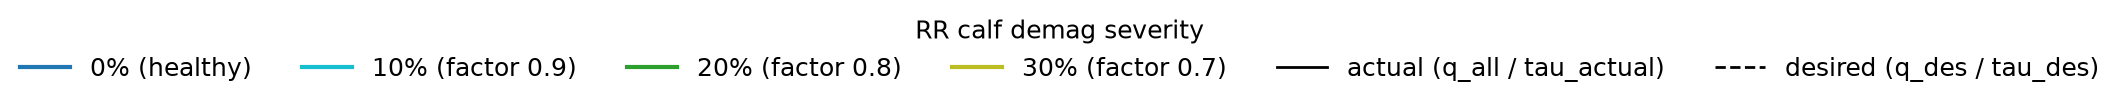

In [70]:
plot_severity_legend(PLOT_CASES, style_note=[
    ("actual (q_all / tau_actual)", "-"),
    ("desired (q_des / tau_des)", "--"),
])

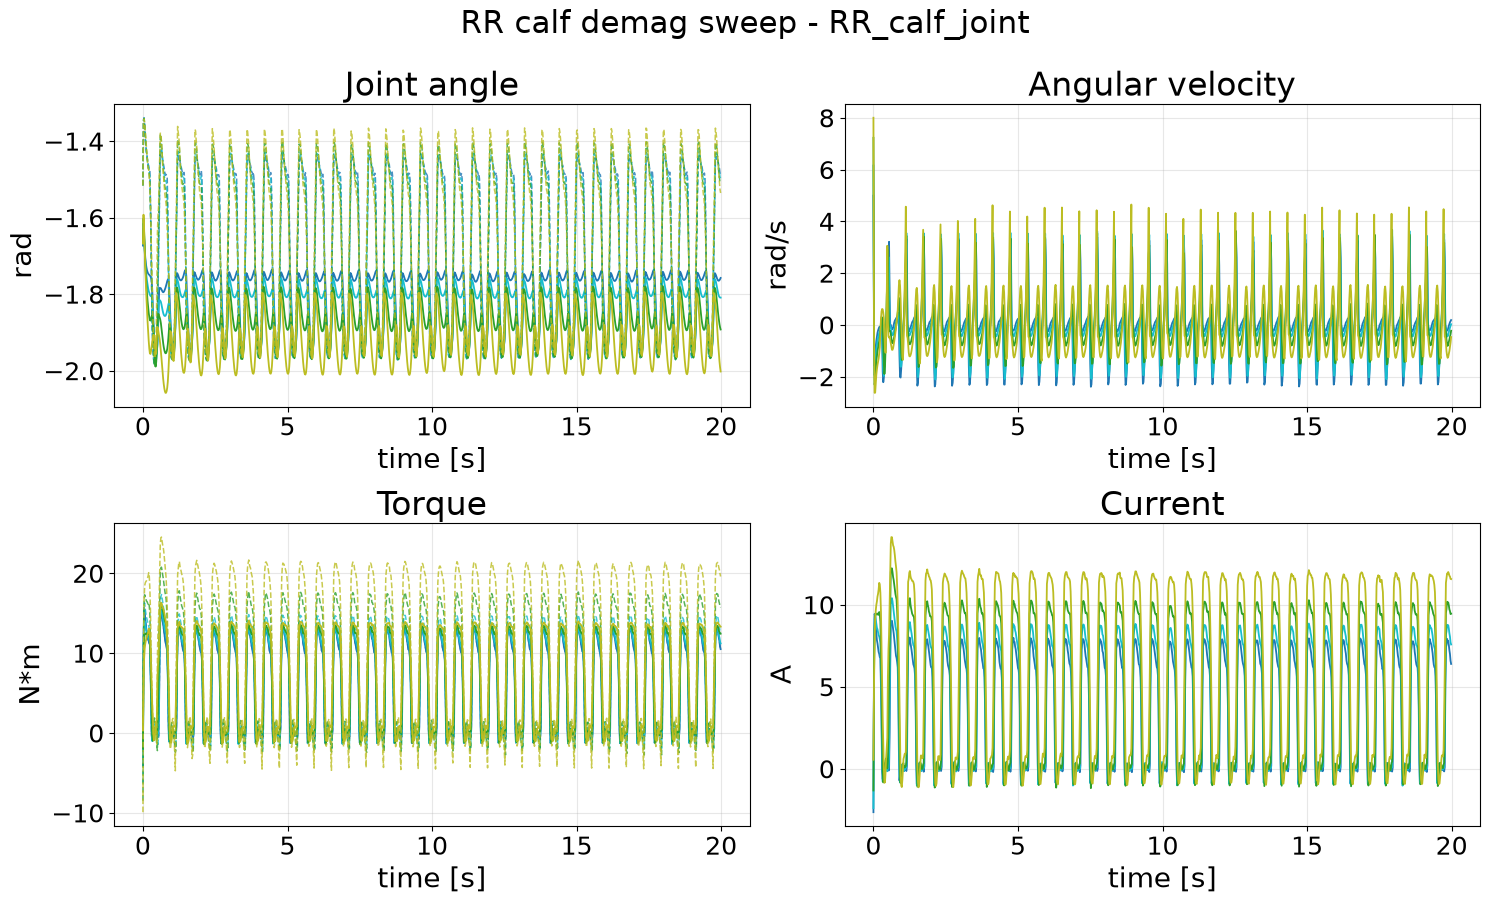

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    ax.plot(s["t"], s["q"],     color=s["color"], lw=1.3, ls="-")
    ax.plot(s["t"], s["q_des"], color=s["color"], lw=1.1, ls="--", alpha=0.8)
ax.set_title("Joint angle")
ax.set_ylabel("rad")

ax = axes[1, 0]
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    ax.plot(s["t"], s["tau"],     color=s["color"], lw=1.3, ls="-")
    ax.plot(s["t"], s["tau_des"], color=s["color"], lw=1.1, ls="--", alpha=0.8)
ax.set_title("Torque")
ax.set_ylabel("N*m")

panels = [
    ("qd", "Angular velocity", "rad/s", axes[0, 1]),
    ("I",  "Current",          "A",     axes[1, 1]),
]
for field, title, unit, ax in panels:
    for key, _, _, _ in PLOT_CASES:
        s = series[key]
        ax.plot(s["t"], s[field], color=s["color"], lw=1.3)
    ax.set_title(title)
    ax.set_ylabel(unit)

for ax in axes.flat:
    ax.set_xlabel("time [s]")
    ax.tick_params(labelbottom=True)
    ax.grid(alpha=0.3)

fig.suptitle(f"RR calf demag sweep - {JOINT}", y=1.00)
fig.tight_layout()
fig.savefig("./plots_RR_calf_demag_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

The full 20 s view above is dense (~33 gait cycles overlapping); zooming into a short steady-state window makes the individual waveforms legible.

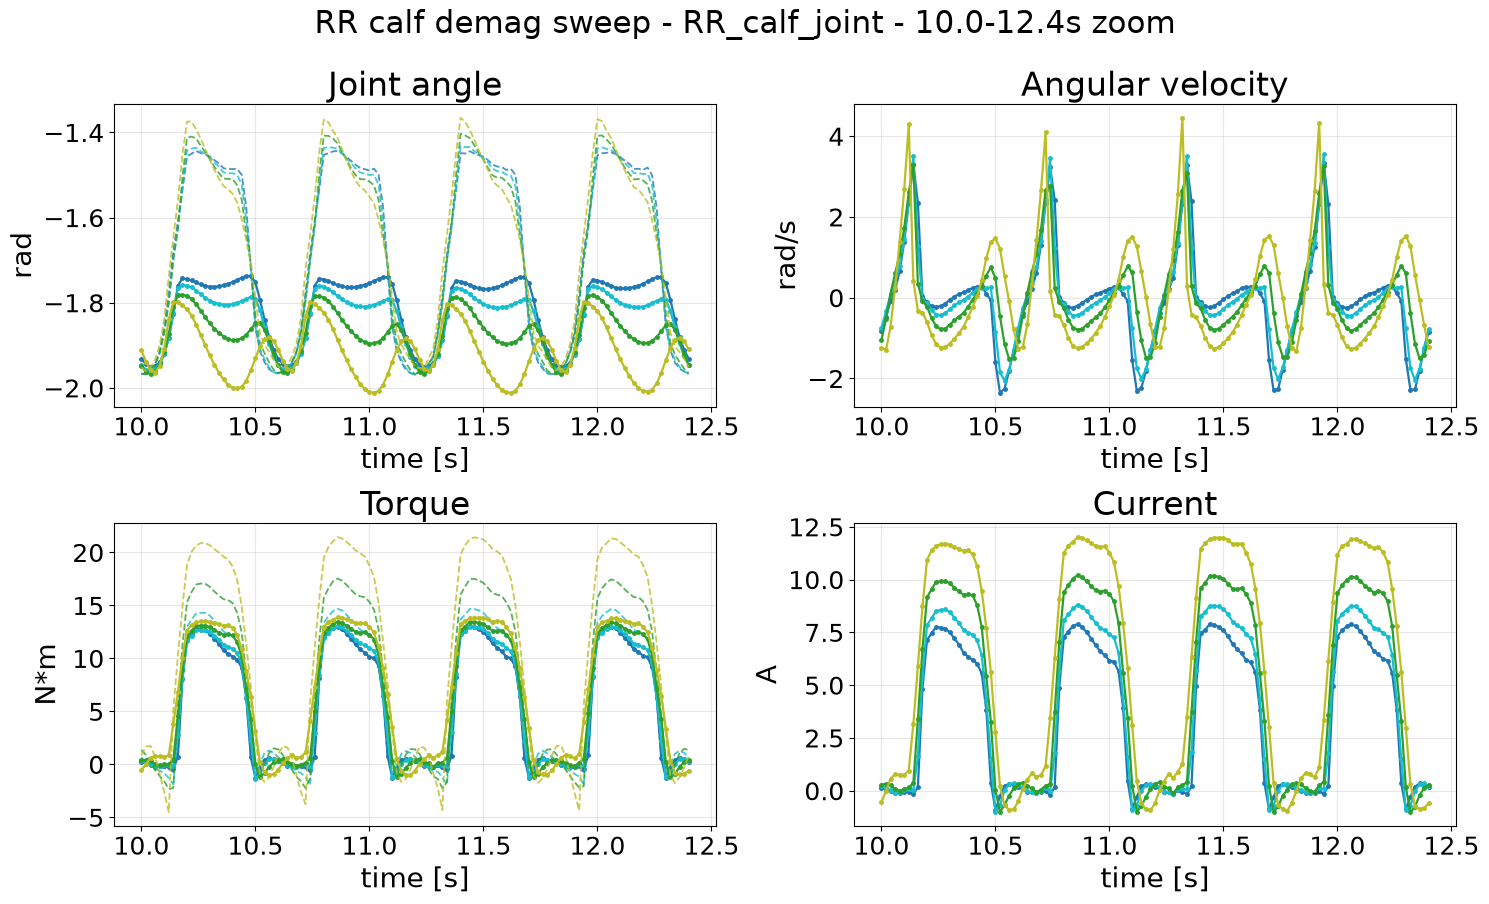

In [72]:
# Zoomed steady-state window: ~4 gait cycles (period=0.6 s from env.yaml
# phase.period), well past the initial transient.
T0, T1 = 10.0, 12.4  # 4 cycles @ 0.6 s

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 9))

ax = axes2[0, 0]
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    mask = (s["t"] >= T0) & (s["t"] <= T1)
    ax.plot(s["t"][mask], s["q"][mask],     color=s["color"], lw=1.6, ls="-",  marker="o", ms=2.5)
    ax.plot(s["t"][mask], s["q_des"][mask], color=s["color"], lw=1.3, ls="--", alpha=0.8)
ax.set_title("Joint angle")
ax.set_ylabel("rad")

ax = axes2[1, 0]
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    mask = (s["t"] >= T0) & (s["t"] <= T1)
    ax.plot(s["t"][mask], s["tau"][mask],     color=s["color"], lw=1.6, ls="-",  marker="o", ms=2.5)
    ax.plot(s["t"][mask], s["tau_des"][mask], color=s["color"], lw=1.3, ls="--", alpha=0.8)
ax.set_title("Torque")
ax.set_ylabel("N*m")

for field, title, unit, ax in [
    ("qd", "Angular velocity", "rad/s", axes2[0, 1]),
    ("I",  "Current",          "A",     axes2[1, 1]),
]:
    for key, _, _, _ in PLOT_CASES:
        s = series[key]
        mask = (s["t"] >= T0) & (s["t"] <= T1)
        ax.plot(s["t"][mask], s[field][mask], color=s["color"], lw=1.6, marker="o", ms=2.5)
    ax.set_title(title)
    ax.set_ylabel(unit)

for ax in axes2.flat:
    ax.set_xlabel("time [s]")
    ax.tick_params(labelbottom=True)
    ax.grid(alpha=0.3)

fig2.suptitle(f"RR calf demag sweep - {JOINT} - {T0:.1f}-{T1:.1f}s zoom", y=1.00)
fig2.tight_layout()
fig2.savefig("./plots_RR_calf_demag_sweep_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

## Driver-side torque estimate (tau_est) — what real hardware would report

$$\hat\tau = I_{actual} \cdot K_{t,nom}$$

As its own plot, separate from the actual/desired torque above. A real Go2
has no torque sensor; its `effort` telemetry is exactly this — measured
phase current times the *nominal* Kt the firmware assumes, regardless of
`factor`. Under demag it over-reports relative to the true `tau_actual`
(compare against the Torque panel above): the higher the severity, the more
this driver-reported number diverges from what's physically delivered.

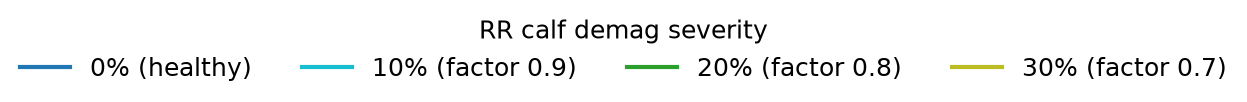

In [73]:
plot_severity_legend(PLOT_CASES)

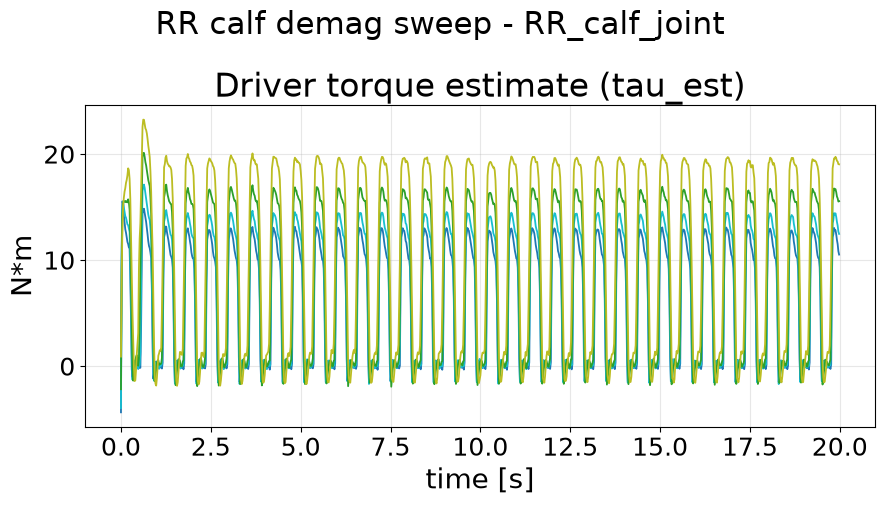

In [74]:
fig5, ax = plt.subplots(figsize=(9, 5))
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    ax.plot(s["t"], s["tau_est"], color=s["color"], lw=1.3)
ax.set_title("Driver torque estimate (tau_est)")
ax.set_xlabel("time [s]")
ax.set_ylabel("N*m")
ax.grid(alpha=0.3)

fig5.suptitle(f"RR calf demag sweep - {JOINT}", y=1.00)
fig5.tight_layout()
fig5.savefig("./plots_RR_calf_demag_sweep_tau_est.png", dpi=150, bbox_inches="tight")
plt.show()

Same steady-state window as the other zoomed plots, for a legible close-up.

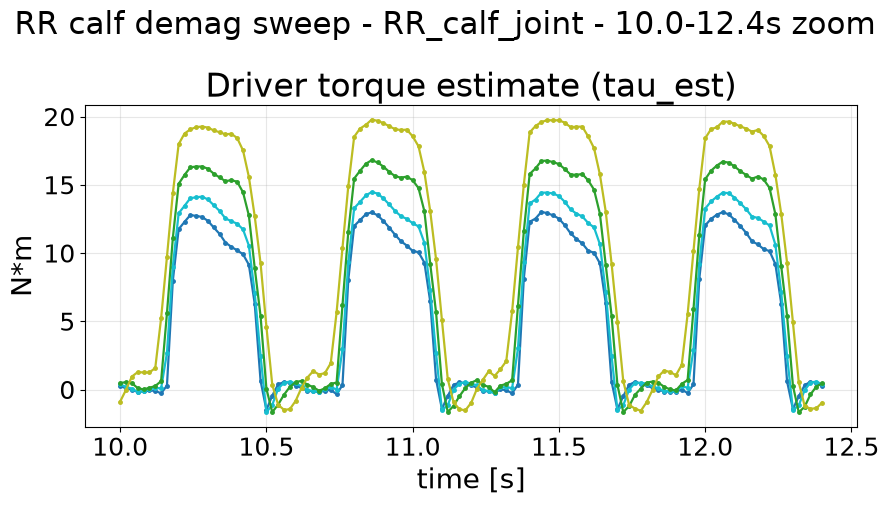

In [75]:
fig6, ax = plt.subplots(figsize=(9, 5))
for key, _, _, _ in PLOT_CASES:
    s = series[key]
    mask = (s["t"] >= T0) & (s["t"] <= T1)
    ax.plot(s["t"][mask], s["tau_est"][mask], color=s["color"], lw=1.6, marker="o", ms=2.5)
ax.set_title("Driver torque estimate (tau_est)")
ax.set_xlabel("time [s]")
ax.set_ylabel("N*m")
ax.grid(alpha=0.3)

fig6.suptitle(f"RR calf demag sweep - {JOINT} - {T0:.1f}-{T1:.1f}s zoom", y=1.00)
fig6.tight_layout()
fig6.savefig("./plots_RR_calf_demag_sweep_tau_est_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

## Body orientation — how much does the body wobble?

`base_rpy` (roll/pitch/yaw, ZYX intrinsic Euler from `base_quat`, computed in
`run_demag_experiment.py`) is body-level, not per-joint, so it's extracted
separately from the `RR_calf_joint` series above. Plotted in degrees for
readability. Heading-lock directly regulates yaw (target 0 rad), so yaw
wobble is a direct measure of how hard the controller is fighting the
asymmetric drag from the demagnetized RR calf; roll/pitch show the
side-to-side and fore-aft body rock.

In [76]:
body_series = {}
for key, label, _, color in CASES:
    d = runs[key]["data"]
    meta = runs[key]["meta"]
    rpy_deg = np.degrees(d["base_rpy"])  # (N, 3) = [roll, pitch, yaw]
    t = np.arange(meta["num_steps"]) * meta["dt"]
    body_series[key] = {
        "t": t, "roll": rpy_deg[:, 0], "pitch": rpy_deg[:, 1], "yaw": rpy_deg[:, 2],
        "label": label, "color": color,
    }

print(f"{'case':10s} {'roll RMS':>9s} {'pitch RMS':>10s} {'yaw RMS':>9s}  (deg, full 20s)")
for key, _, _, _ in CASES:
    b = body_series[key]
    print(f"{key:10s} {np.sqrt((b['roll']**2).mean()):9.2f} "
          f"{np.sqrt((b['pitch']**2).mean()):10.2f} {np.sqrt((b['yaw']**2).mean()):9.2f}")

case        roll RMS  pitch RMS   yaw RMS  (deg, full 20s)
healthy         0.23       0.29      2.71
RR_0.90         0.77       0.79      3.93
RR_0.80         1.70       1.84      8.07
RR_0.70         2.87       3.02     13.70
RR_0.60         4.39       4.28     17.64
RR_0.40         6.67       6.33     20.22


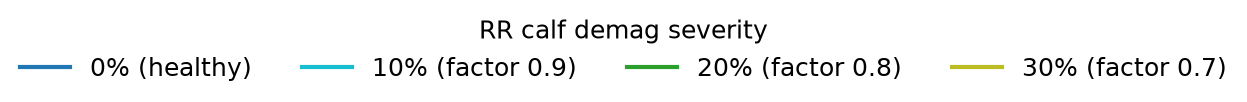

In [77]:
plot_severity_legend(PLOT_CASES)

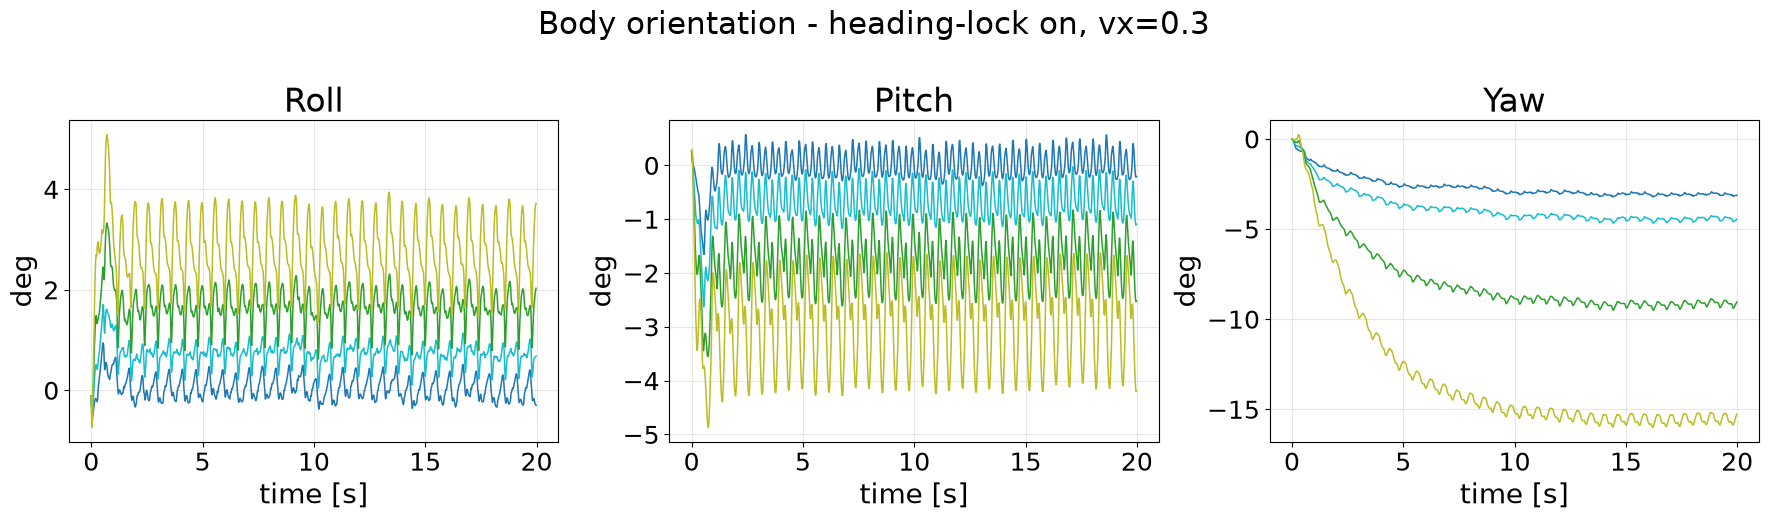

In [78]:
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))

for field, title, ax in [
    ("roll",  "Roll",  axes3[0]),
    ("pitch", "Pitch", axes3[1]),
    ("yaw",   "Yaw",   axes3[2]),
]:
    for key, _, _, _ in PLOT_CASES:
        b = body_series[key]
        ax.plot(b["t"], b[field], color=b["color"], lw=1.1)
    ax.set_title(title)
    ax.set_xlabel("time [s]")
    ax.set_ylabel("deg")
    ax.tick_params(labelbottom=True)
    ax.grid(alpha=0.3)

fig3.suptitle("Body orientation - heading-lock on, vx=0.3", y=1.03)
fig3.tight_layout()
fig3.savefig("./plots_RR_calf_demag_sweep_rpy.png", dpi=150, bbox_inches="tight")
plt.show()

Same steady-state window as the joint-level plots, for a legible close-up.

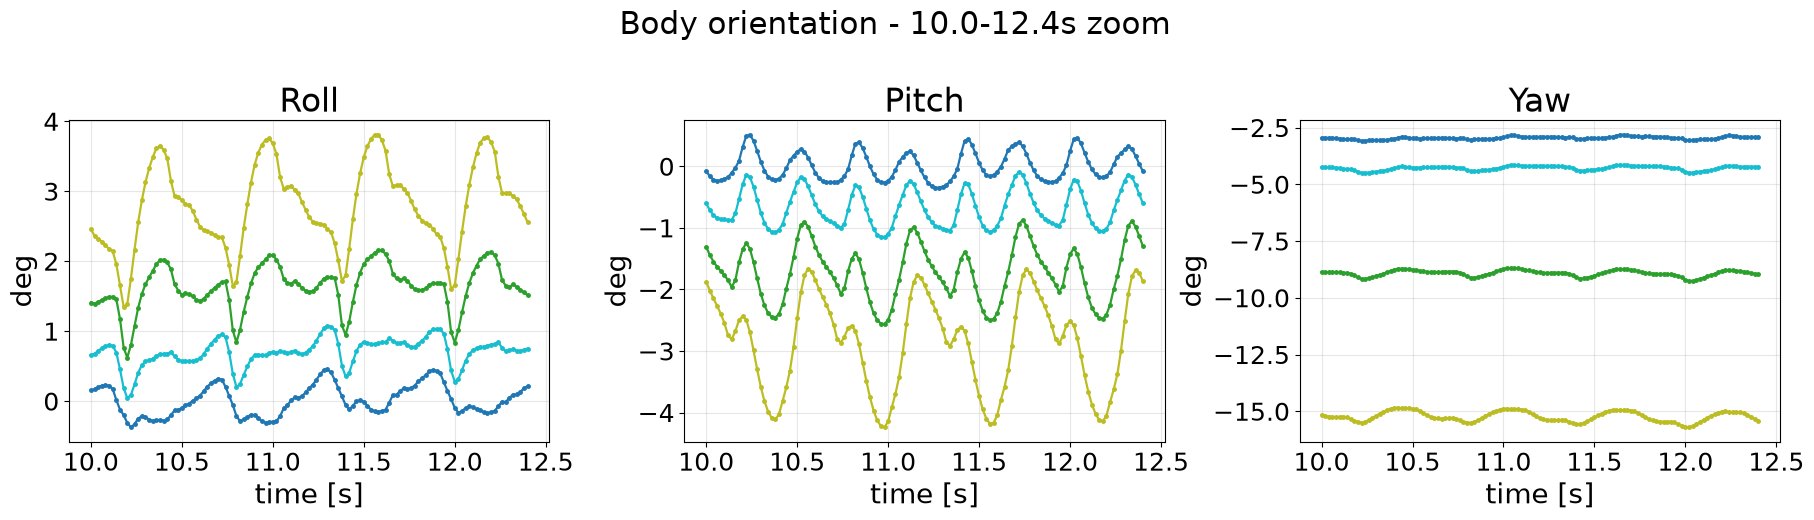

In [79]:
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5))

for field, title, ax in [
    ("roll",  "Roll",  axes4[0]),
    ("pitch", "Pitch", axes4[1]),
    ("yaw",   "Yaw",   axes4[2]),
]:
    for key, _, _, _ in PLOT_CASES:
        b = body_series[key]
        mask = (b["t"] >= T0) & (b["t"] <= T1)
        ax.plot(b["t"][mask], b[field][mask], color=b["color"], lw=1.6, marker="o", ms=2.5)
    ax.set_title(title)
    ax.set_xlabel("time [s]")
    ax.set_ylabel("deg")
    ax.tick_params(labelbottom=True)
    ax.grid(alpha=0.3)

fig4.suptitle(f"Body orientation - {T0:.1f}-{T1:.1f}s zoom", y=1.03)
fig4.tight_layout()
fig4.savefig("./plots_RR_calf_demag_sweep_rpy_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

## Is V_bus (or the rated-current limit) actually the bottleneck?

Two independent checks with the corrected `Kt_nom = 1.6458`, plus a direct
counterfactual — rather than repeating the log's guessed
"possible current saturation" label.

In [80]:
# 1) Required bus voltage vs the configured V_bus limit.
#    V = R * I_des + Ke_nom*gr * omega   (controller always assumes nominal
#    Ke -- see go2_constants.py: R=0.66 Ohm, V_bus=30.8 V, confirmed live via
#    actuator.cfg.V_bus / actuator._V_bus, not randomized in this play env
#    -- randomize_V_bus is not in the active 'reset' event list).
R = 0.66
V_BUS = 30.8

print(f"{'case':16s} {'net_dx[m]':>10s} {'mean_vx':>9s} {'max|V_req|':>11s} "
      f"{'V_bus':>7s} {'max|I_cmd|':>11s} {'I_limit':>8s} {'I_cmd==I_des?':>14s}")
I_LIMIT = 45.0 / KT_NOMINAL_JOINT  # calf effort_limit / Kt_nom
for key, label, _, _ in CASES:
    d = runs[key]["data"]
    meta = runs[key]["meta"]
    col = meta["q_all_joint_names"].index(JOINT)
    x, vx = d["base_pos"][:, 0], d["base_lin_vel"][:, 0]
    tau_des, qd = d["tau_des"][:, col], d["qd_all"][:, col]
    I_des = tau_des / KT_NOMINAL_JOINT
    V_req = R * I_des + KT_NOMINAL_JOINT * qd
    I_cmd = d["I_cmd"][:, col]
    no_clamp = np.allclose(I_cmd, I_des, atol=1e-3)
    print(f"{key:16s} {x[-1]-x[0]:10.3f} {vx[-250:].mean():9.3f} "
          f"{np.abs(V_req).max():10.1f}V {V_BUS:6.1f}V "
          f"{np.abs(I_cmd).max():10.2f}A {I_LIMIT:7.2f}A {str(no_clamp):>14s}")

case              net_dx[m]   mean_vx  max|V_req|   V_bus  max|I_cmd|  I_limit  I_cmd==I_des?
healthy               4.594     0.234        6.7V   30.8V       9.57A   27.34A           True
RR_0.90               4.289     0.220        7.6V   30.8V      10.54A   27.34A           True
RR_0.80               3.729     0.196        8.5V   30.8V      12.62A   27.34A           True
RR_0.70               2.963     0.165        9.2V   30.8V      14.91A   27.34A           True
RR_0.60               2.234     0.134        9.6V   30.8V      16.30A   27.34A           True
RR_0.40               0.475     0.036       16.2V   30.8V      23.36A   27.34A           True


**Result: neither limit is actually hit.** Even at 60% severity, required
voltage peaks around 16 V against a 30.8 V bus, and commanded current peaks
around 23 A against a 27.3 A rated-current bound — `I_cmd == I_des` exactly
in every case, meaning **no clamping happens at all** with the corrected
constant. (The earlier "V_bus/current saturation" conclusion was an artifact
of the `Kt=0.128` bug — it made computed currents/voltages look ~2x larger
than real, and the wrong `I_limit=55.5A` looked unreached when the true
`27.3A` limit was actually being approached.)

## Counterfactual: does removing the V_bus limit help RR_0.40 (60%) walk?

Re-ran the RR_0.40 (60% severity) case with `--vbus-override 1000` (~unlimited
bus voltage), everything else identical, to test directly instead of just
computing it.

In [81]:
for tag, path in [
    ("RR_0.40, V_bus=30.8 (default)",  "./data/gait05/RR_0.40.npz"),
    ("RR_0.40, V_bus=1000 (~unlimited)", "./data/gait05_vbus1000/RR_0.40.npz"),
]:
    d = np.load(path, allow_pickle=True)
    x, vx = d["base_pos"][:, 0], d["base_lin_vel"][:, 0]
    print(f"{tag:36s} net_dx={x[-1]-x[0]:7.3f} m   mean_vx(last 5s)={vx[-250:].mean():7.3f} m/s")

RR_0.40, V_bus=30.8 (default)        net_dx=  0.475 m   mean_vx(last 5s)=  0.036 m/s
RR_0.40, V_bus=1000 (~unlimited)     net_dx=  0.476 m   mean_vx(last 5s)=  0.036 m/s


**Net displacement is identical (0.475 m vs 0.476 m)** — removing the
voltage clamp entirely makes no difference. This confirms the degraded gait
at high demag severity is **not** an electrical-saturation artifact; it is a
genuine physical torque deficit (lower `Kt` delivers less N·m per amp for
the same current) that this policy — trained without any actuator-fault
domain randomization — has no strategy to compensate for. The graceful
degradation with severity (`healthy` 4.59 m → 20% 3.73 m → 40% 2.23 m → 60%
0.48 m net displacement over 20 s) is consistent with a policy generalizing
partially into a mild out-of-distribution fault (20-40%) and failing outright
once the single leg's torque authority drops too far (60%).